# Deep Species Distribution Models

![alt text](images/sdm-diagram.png "SDM")

Species Distribution Models (SDMs) estimate the probability (or relative intensity) of a species occurring at a given location based on environmental covariates. In this exercise we build a **deep learning SDM** that jointly models multiple species at once using presence-only occurrence records.

**Objectives:**
1. Formulate a custom loss function for presence-only data (Deep MaxEnt)
2. Train a multi-layer perceptron (MLP)
3. Evaluate species-level predictions using AUC on presence-absence data
4. Project the trained model onto a spatial grid to produce habitat suitability maps

**Data:** Swiss biodiversity records (`data/SWItrain_po.csv`) and environmental rasters covering Switzerland.

## 1. Imports

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

## 2. Model Architecture

### 2.1 Loss function — Deep MaxEnt

For presence-only data we cannot use standard cross-entropy (we have no confirmed absences). Instead we use a **MaxEnt-style loss** (Ryckewaert et al. 2026) that contrasts the predicted intensity at observed presence sites against the intensities across the rest of the batch.

$$L(y,\lambda)=\sum_{ij} y_{ij} \cdot \log(\frac{\lambda_{ij}}{\sum_{b \in B} \lambda_{bj}})$$

where $y_{ij} \in \{0,1\}$ is the presence indicator for species $j$ at site $i$, $B$ is the batch, and $\lambda_{ij} = e^{f_\theta(x_i)_j}$ is the predicted intensity from the network. Maximising this objective encourages the model to assign high intensity to observed presences relative to background sites.

In [20]:
class DeepMaxEntLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        # log-softmax over the batch dimension gives log(λ_ij / Σ_b λ_bj)
        logp = input.log_softmax(dim=0)
        loss_num = -(target * logp).sum()
        loss_den = target.sum().clamp_min(1e-8)
        return loss_num / loss_den

### 2.2 Network — Residual MLP

We use a simple **multi-layer perceptron**

*add a bit more detail*

In [21]:
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int, hidden_layers: int):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_size, hidden_size) for _ in range(hidden_layers)]
        )

        # Expose backbone so it can be frozen externally for transfer learning
        self.feature_extractor = nn.ModuleDict({
            "fc1": self.fc1,
            "hidden_layers": self.hidden_layers,
        })

        self.output_layer = nn.Linear(hidden_size, output_size, bias=False)

    def get_features(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the backbone only (before the output head)."""
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = x + F.relu(layer(x))  # residual connection
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.output_layer(self.get_features(x))

## 3. Data Loading & Preprocessing

We work with two complementary datasets:

| Dataset | File | Description |
|---|---|---|
| **Presence-only (PO)** | `SWItrain_po.csv` | Occurrence records — we only know *where* a species was seen |
| **Presence-absence (PA)** | `SWItest_pa.csv` + `SWItest_env.csv` | Survey data with confirmed presences *and* absences; used for evaluation only |

We standarize the data by fitting a `StandardScaler` on the PO data and applying the same transform to PA. 

In [22]:
from sklearn.preprocessing import StandardScaler

po_path  = 'data/SWItrain_po.csv'
pa_path  = 'data/SWItest_pa.csv'
env_path = 'data/SWItest_env.csv'

index_col = ['x', 'y']

df_po  = pd.read_csv(po_path)
df_pa  = pd.read_csv(pa_path)
df_env = pd.read_csv(env_path)

covariates = df_env.columns[4:].tolist()
species    = sorted(df_po['spid'].unique().tolist())

# ── Presence-absence ──────────────────────────────────────────────────────────
Y_pa = df_pa[species].copy()
X_pa = df_env[covariates].copy()
Y_pa[species] = np.clip(Y_pa[species], 0, 1)  # ensure binary labels

# ── Presence-only: aggregate multiple observations per grid cell ───────────────
Y_po = (
    df_po.pivot_table(index=index_col, columns='spid', aggfunc='size', fill_value=0)
         .reset_index()
)
X_po = (
    df_po.groupby(index_col)[covariates]
         .mean()
         .reset_index()
)
XY_po = pd.merge(X_po, Y_po, on=index_col, how='inner')
X_po  = XY_po[covariates].copy()
Y_po  = XY_po[species].copy()

# ── Standardise covariates (fit on PA, apply to PO) ───────────────────────────
scaler = StandardScaler()
X_pa   = scaler.fit_transform(X_pa)
X_po   = scaler.transform(X_po)

print(f'Species: {len(species)}  |  PO sites: {len(X_po)}  |  PA sites: {len(X_pa)}  |  Covariates: {len(covariates)}')

Species: 30  |  PO sites: 11429  |  PA sites: 10013  |  Covariates: 13


## 4. Training

We train the MLP on the presence-only data using the Deep MaxEnt loss. After each epoch we can observe how the presence-absence test set by computing the **AUC-ROC** for each species — a threshold-free metric that measures how well the model separates presences from absences.

*add more details, why AUC*

Epoch   0 | mean AUC 0.515  (random init)
Epoch   5 | loss 5.2329 | mean AUC 0.807
Epoch  10 | loss 5.1130 | mean AUC 0.831
Epoch  15 | loss 5.0745 | mean AUC 0.836
Epoch  20 | loss 5.0552 | mean AUC 0.838


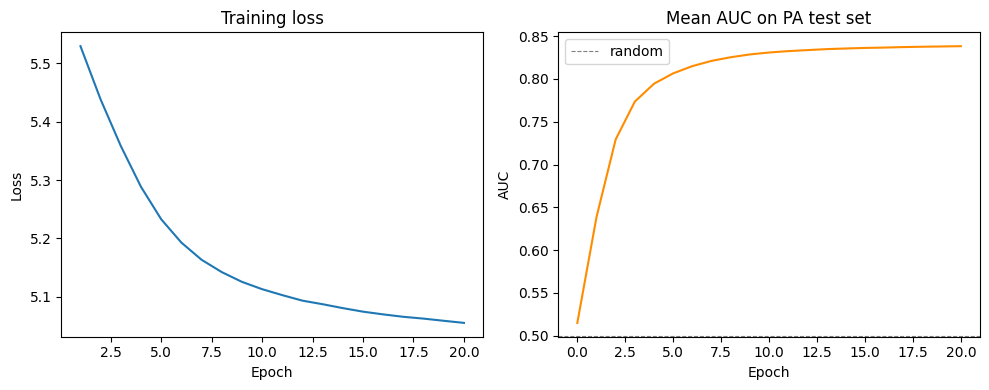

In [23]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_FEATURES   = len(covariates)
N_SPECIES    = len(species)
N_EPOCHS     = 20
LR           = 1e-4
BATCH_SIZE   = 256
WEIGHT_DECAY = 3e-3

# if you have a gpu available this would use it and hopefully run much (or a bit) faster (;
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# ── Tensors & data loader ─────────────────────────────────────────────────────
X_po_t  = torch.tensor(X_po, dtype=torch.float32)
Y_po_t  = torch.tensor(Y_po.values, dtype=torch.float32)
X_pa_t  = torch.tensor(X_pa, dtype=torch.float32).to(device)
Y_pa_np = Y_pa.values  # kept as numpy for roc_auc_score

po_loader = DataLoader(TensorDataset(X_po_t, Y_po_t), batch_size=BATCH_SIZE, shuffle=True)

# ── Model, loss, optimiser ────────────────────────────────────────────────────
model     = MLP(N_FEATURES, hidden_size=100, output_size=N_SPECIES, hidden_layers=2).to(device)
criterion = DeepMaxEntLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── To compute AUC ─────────────────────────────────────────────────────────
def evaluate_auc(model):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_pa_t)).cpu().numpy()
    # Only compute AUC for species with at least one positive example
    return [
        roc_auc_score(Y_pa_np[:, s], probs[:, s])
        for s in range(N_SPECIES) if Y_pa_np[:, s].sum() > 0
    ]

# ── Training loop ─────────────────────────────────────────────────────────────
history = {'loss': [None], 'mean_auc': [sum(evaluate_auc(model)) / N_SPECIES]}
print(f"Epoch   0 | mean AUC {history['mean_auc'][0]:.3f}  (random init)")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    losses = []
    # For each epoch we iterate over the batches that are well defined in the DataLoader. Each batch is a tuple of (covariates, presence counts) for a subset of the PO sites.
    for xb, yb in po_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    aucs = evaluate_auc(model)
    history['loss'].append(sum(losses) / len(losses))
    history['mean_auc'].append(sum(aucs) / len(aucs))

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | loss {history['loss'][-1]:.4f} | mean AUC {history['mean_auc'][-1]:.3f}")

# ── Some plots ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(range(1, N_EPOCHS + 1), history['loss'][1:])
ax1.set(title='Training loss', xlabel='Epoch', ylabel='Loss')

ax2.plot(history['mean_auc'], color='darkorange')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random')
ax2.legend()
ax2.set(title='Mean AUC on PA test set', xlabel='Epoch', ylabel='AUC')

plt.tight_layout()
plt.show()

## 5. Building Habitat Suitability Maps

*Comment: Check the maps and scale*

One of the main objectives one building an SDM is to preduce a **spatial map** showing where a species is predicted to occur. This is not only pretty, but can inform conservation decisions, and help us understand the ecology of the species.

We do this by:
1. Loading all environmental raster layers in the same covariate order used during training. This rasters contain values at a specific resolution for the whole country (or area of study)
2. Flattening the raster grid into a matrix of pixels × covariates and running a forward pass
3. Converting raw logits to intensities ($\lambda = e^{f_\theta}$) and normalising per species so values sum to 1 — giving a *relative* habitat suitability

> **Note:** The output is a *relative* intensity, not an absolute probability. It tells you which areas are more suitable compared to others, but cannot be directly interpreted as "probability of presence".

In [24]:
import rasterio
import geopandas as gpd
from rasterio.features import geometry_mask
from pathlib import Path

tiff_dir = Path('data/rasters')
border   = gpd.read_file('data/swi.gpkg')

# ── Load rasters in covariate order ──────────────────────────────────────────
rasters       = {Path(f).stem: rasterio.open(f) for f in sorted(tiff_dir.glob('*.tif'))}
ref           = next(iter(rasters.values()))
height, width = ref.height, ref.width

stack       = np.stack([rasters[c].read(1) for c in covariates], axis=-1)  # (H, W, F)
nodata_mask = np.isnan(stack).any(axis=-1)

# Mask pixels outside the Swiss border
land_mask   = geometry_mask(border.geometry, transform=ref.transform, invert=True, out_shape=(height, width))
nodata_mask = nodata_mask | ~land_mask

# ── Predict on the full raster grid ──────────────────────────────────────────
flat  = stack.reshape(-1, len(covariates))
X_map = torch.tensor(scaler.transform(flat), dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    raw_intensities = torch.exp(model(X_map)).cpu().numpy()  # λ = e^{f_θ}

intensity_maps = raw_intensities.reshape(height, width, len(species))
intensity_maps[nodata_mask] = np.nan

# # Normalise each species map so values sum to 1 (relative suitability)
# intensity_maps = intensity_maps / np.nansum(intensity_maps, axis=(0, 1), keepdims=True)

for src in rasters.values():
    src.close()

/Users/pubillap/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


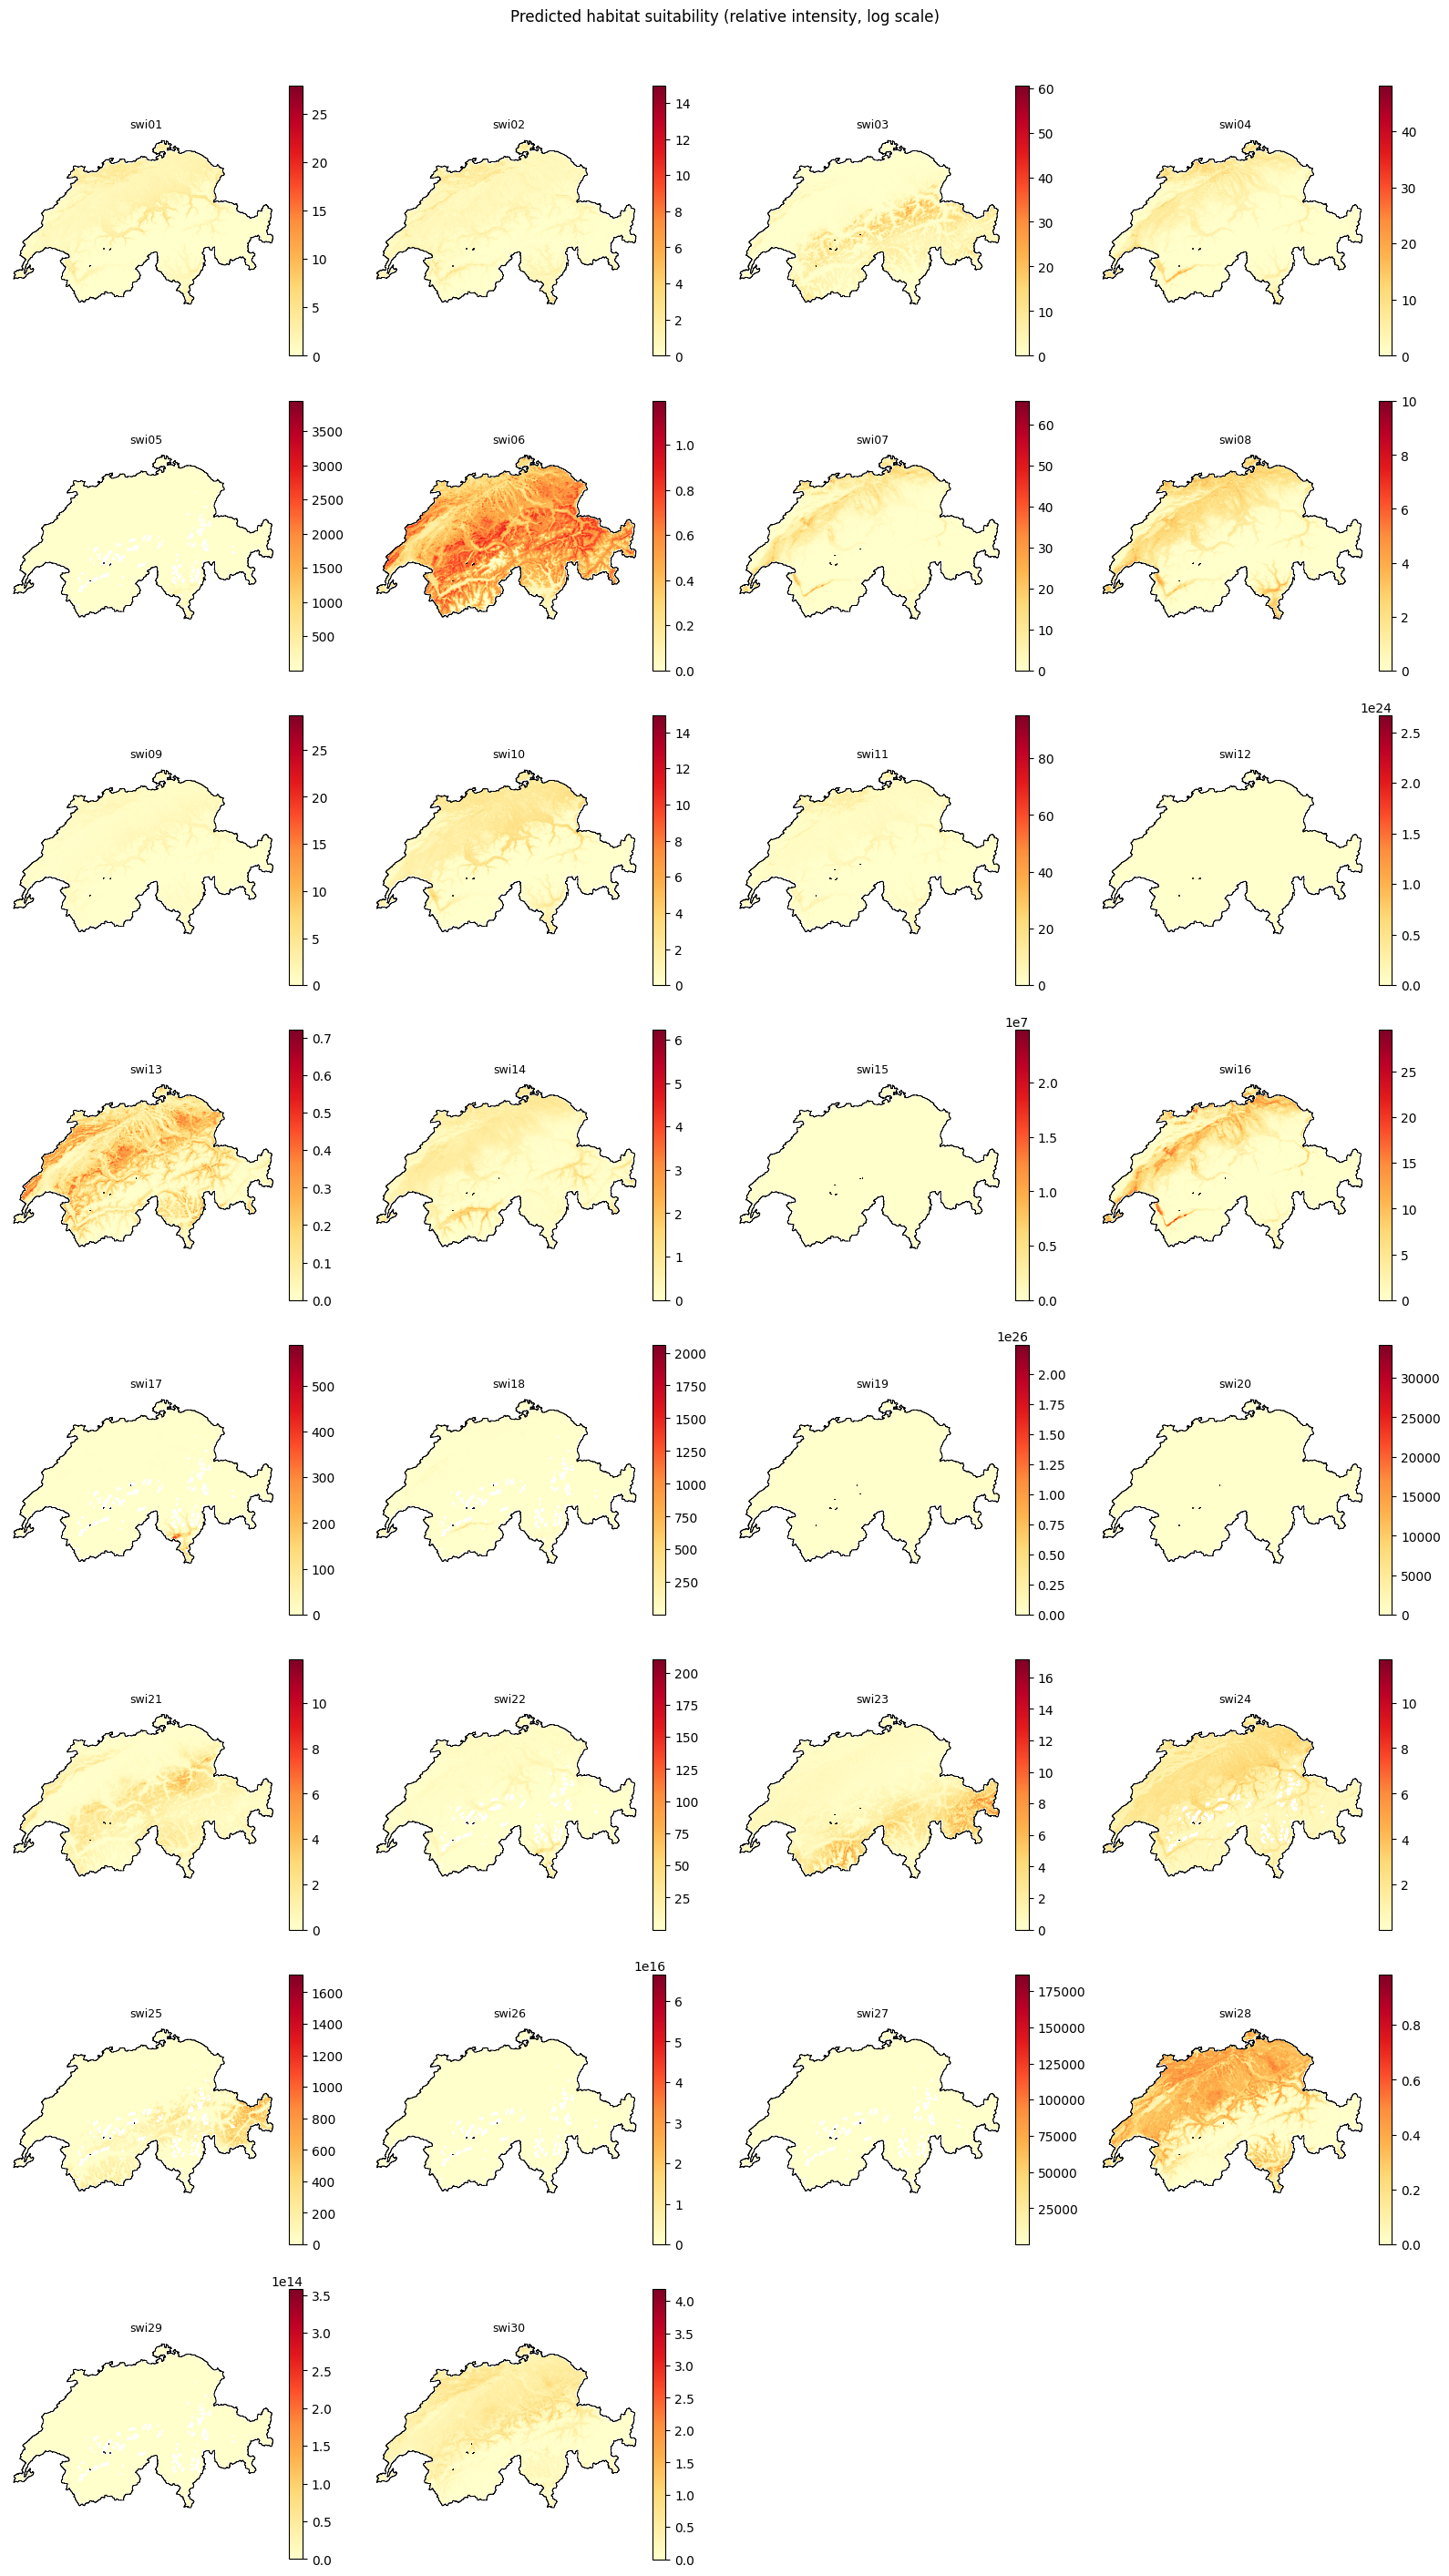

In [25]:
# from matplotlib.colors import LogNorm

ncols  = 4
nrows  = int(np.ceil(len(species) / ncols))
extent = [ref.bounds.left, ref.bounds.right, ref.bounds.bottom, ref.bounds.top]

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))

for ax, sp, i in zip(axes.flat, species, range(len(species))):
    im = ax.imshow(
        intensity_maps[:, :, i], origin='upper', extent=extent,
        cmap='YlOrRd'
    )
    border.boundary.plot(ax=ax, linewidth=0.6, color='black')
    ax.set_title(sp, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

for ax in axes.flat[len(species):]:
    ax.axis('off')

plt.suptitle('Predicted habitat suitability (relative intensity, log scale)', y=1.01)
plt.tight_layout()
plt.show()

# Some Exercises (Ideas)

- HyperParameter Tuning
- Trying and comparing different Losses
- Including Sat. Images or some Embedding
- Data Integration (What if some PA data is available for training?)
- Explainability (which covariates are more important, how to tell in DL)